In [2]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, KFold, cross_validate, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer

### Data Loading-

In [3]:
warnings.filterwarnings("ignore")

In [6]:
DATA_PATH = "D:/Dhirubhai Ambani University/ML/Lab 4/Dataset/AB_NYC_2019.csv"

In [7]:
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}\n"
        "Change DATA_PATH to the location of your Airbnb CSV file."
    )

In [8]:
df = pd.read_csv(DATA_PATH)

In [11]:
print("Shape:", df.shape)
print("\nColumns:")
for i in df.columns.tolist():
    print(i)

Shape: (48895, 16)

Columns:
id
name
host_id
host_name
neighbourhood_group
neighbourhood
latitude
longitude
room_type
price
minimum_nights
number_of_reviews
last_review
reviews_per_month
calculated_host_listings_count
availability_365


### Data Cleaning-

In [12]:
duplicate_count = df.duplicated().sum()
print("\nDuplicate rows:", duplicate_count)

df = df.drop_duplicates().copy()


Duplicate rows: 0


#### Remove irrelevant identifier / free-text columns

In [13]:
columns_to_drop = [
    "id",
    "host_id",
    "name",
    "host_name",
    "last_review"
]

In [20]:
# Keep last_review temporarily because we use it to create
# has_review, year and month.
columns_to_drop_without_date = [
    "id",
    "host_id",
    "name",
    "host_name"
]

In [15]:
df = df.drop(
    columns=[
        c for c in columns_to_drop_without_date
        if c in df.columns
    ],
    errors="ignore"
)

### Feature Engineering

In [16]:
if "last_review" in df.columns:

    df["last_review"] = pd.to_datetime(
        df["last_review"],
        errors="coerce"
    )

    # A listing has a review if last_review is available
    df["has_review"] = (
        df["last_review"].notna()
    ).astype(int)

    # These are optional exploratory features.
    # They are NOT used in the final feature set because
    # they showed very weak relationship with price.
    df["last_review_year"] = (
        df["last_review"].dt.year
    )

    df["last_review_month"] = (
        df["last_review"].dt.month
    )

else:

    df["has_review"] = 0

### Target Cleaning-

In [17]:
# Ensure price is numeric
df["price"] = pd.to_numeric(
    df["price"],
    errors="coerce"
)

In [18]:
# Remove missing and zero/negative prices
before_price_cleaning = len(df)

df = df[
    df["price"].notna() &
    (df["price"] > 0)
].copy()

In [19]:
print("\nRows removed because of invalid price:",
      before_price_cleaning - len(df))


Rows removed because of invalid price: 11


In [21]:
# IMPORTANT:
# Calculate the percentile ONCE.
# Do not rerun this filtering cell on an already filtered df.

In [22]:
price_upper_limit = df["price"].quantile(0.99)

print("99th percentile price:", price_upper_limit)

before_outlier = len(df)

df = df[
    df["price"] <= price_upper_limit
].copy()

print(
    "Rows removed as extreme price outliers:",
    before_outlier - len(df)
)

print("Maximum price after treatment:",
      df["price"].max())

99th percentile price: 799.0
Rows removed as extreme price outliers: 474
Maximum price after treatment: 799


### Numerical Cleaning

In [23]:
numeric_raw_columns = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

for col in numeric_raw_columns:

    if col in df.columns:

        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

In [24]:
# Remove impossible negative values.
# Missing values are NOT manually filled here;
# the modeling pipeline handles them using median imputation.

for col in [
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count"
]:

    if col in df.columns:

        df.loc[
            df[col] < 0,
            col
        ] = np.nan

In [25]:
# Availability must be between 0 and 365
if "availability_365" in df.columns:

    df["availability_365"] = df[
        "availability_365"
    ].clip(
        lower=0,
        upper=365
    )

### Feature Engineering

#### Log Transformations

In [26]:
log_source_columns = [
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count"
]

In [27]:
for col in log_source_columns:

    if col not in df.columns:
        raise ValueError(
            f"Required column missing: {col}"
        )

    # Temporary fill only for creating the log feature.
    # The final raw feature is not used in the model.
    values = df[col].fillna(0).clip(lower=0)

    df[
        "log_" + col
    ] = np.log1p(values)

#### Availability ratio

In [28]:
if "availability_365" in df.columns:

    df["availability_ratio"] = (
        df["availability_365"] / 365.0
    )

#### Distance from approximate NYC centre

In [29]:
if (
    "latitude" in df.columns
    and
    "longitude" in df.columns
):

    reference_lat = 40.7128
    reference_lon = -74.0060

    df["distance_from_center"] = np.sqrt(
        (df["latitude"] - reference_lat) ** 2
        +
        (df["longitude"] - reference_lon) ** 2
    )

#### Neighbourhood × room type interaction

In [30]:
if (
    "neighbourhood_group" in df.columns
    and
    "room_type" in df.columns
):

    df["neighbourhood_room"] = (
        df["neighbourhood_group"].astype(str)
        + "_"
        + df["room_type"].astype(str)
    )

### Final Feature Selection

In [31]:
features = [

    # Location
    "neighbourhood_group",
    "neighbourhood",
    "latitude",
    "longitude",
    "distance_from_center",

    # Room information
    "room_type",
    "neighbourhood_room",

    # Skewed numerical variables after log transformation
    "log_minimum_nights",
    "log_number_of_reviews",
    "log_reviews_per_month",
    "log_calculated_host_listings_count",

    # Availability
    "availability_ratio",

    # Review information
    "has_review"
]

In [33]:
target = "price"

In [34]:
missing_features = [
    col
    for col in features
    if col not in df.columns
]

if missing_features:

    raise ValueError(
        "The following selected features are missing:\n"
        + str(missing_features)
    )

In [35]:
X = df[features].copy()
y = df[target].copy()

In [36]:
print("FINAL MODELING DATA-\n")

print("Number of observations:", len(X))
print("Number of features:", len(features))

print("\nSelected features:")
for i, feature in enumerate(features, start=1):
    print(f"{i}. {feature}")

FINAL MODELING DATA-

Number of observations: 48410
Number of features: 13

Selected features:
1. neighbourhood_group
2. neighbourhood
3. latitude
4. longitude
5. distance_from_center
6. room_type
7. neighbourhood_room
8. log_minimum_nights
9. log_number_of_reviews
10. log_reviews_per_month
11. log_calculated_host_listings_count
12. availability_ratio
13. has_review


### Train-Test Split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining samples:", len(X_train))
print("Testing samples :", len(X_test))


Training samples: 38728
Testing samples : 9682


### Define Feature Types

In [38]:
categorical_features = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type",
    "neighbourhood_room"
]

numerical_features = [
    "latitude",
    "longitude",
    "distance_from_center",
    "log_minimum_nights",
    "log_number_of_reviews",
    "log_reviews_per_month",
    "log_calculated_host_listings_count",
    "availability_ratio",
    "has_review"
]

### Pre-processing pipeline

In [39]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [40]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [41]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

### Target Tranformation

In [42]:
# Airbnb prices are strongly right-skewed.
# log1p reduces the effect of very large prices.
# Predictions are automatically converted back using expm1.

target_transformer = FunctionTransformer(
    func=np.log1p,
    inverse_func=np.expm1,
    validate=False
)

### Create Baseline Models

In [43]:
models = {

    "Ridge Regression": Ridge(
        alpha=10.0
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    )
}

In [44]:
model_pipelines = {}

for name, model in models.items():

    base_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

    model_pipelines[name] = (
        TransformedTargetRegressor(
            regressor=base_pipeline,
            transformer=target_transformer
        )
    )

### Training and Comparing Baseline Models

In [45]:
results = []

In [46]:
for name, model in model_pipelines.items():

    print("\nTraining:", name)

    model.fit(
        X_train,
        y_train
    )

    train_pred = model.predict(
        X_train
    )

    test_pred = model.predict(
        X_test
    )

    train_mae = mean_absolute_error(
        y_train,
        train_pred
    )

    test_mae = mean_absolute_error(
        y_test,
        test_pred
    )

    train_rmse = np.sqrt(
        mean_squared_error(
            y_train,
            train_pred
        )
    )

    test_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            test_pred
        )
    )

    train_r2 = r2_score(
        y_train,
        train_pred
    )

    test_r2 = r2_score(
        y_test,
        test_pred
    )

    results.append({
        "Model": name,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train R2": train_r2,
        "Test R2": test_r2
    })


Training: Ridge Regression

Training: Random Forest

Training: Extra Trees


In [47]:
results_df = pd.DataFrame(
    results
).sort_values(
    by="Test RMSE"
).reset_index(drop=True)

In [55]:
print("Baseline Model Comparison-\n")

print(results_df.to_string(index=False))

Baseline Model Comparison-

           Model  Train MAE  Test MAE  Train RMSE  Test RMSE  Train R2  Test R2
   Random Forest  41.770562 44.388126   75.646160  78.756182  0.467282 0.430015
Ridge Regression  45.330934 45.741812   80.053573  80.039571  0.403397 0.411287
     Extra Trees  45.065630 46.265076   80.935553  81.987333  0.390179 0.382286


### Cross-Validation

In [49]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [50]:
cv_results = []

In [51]:
for name, model in model_pipelines.items():

    print("\nCross-validating:", name)

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2"
        },
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV MAE": -scores["test_MAE"].mean(),
        "CV RMSE": -scores["test_RMSE"].mean(),
        "CV R2": scores["test_R2"].mean()
    })


Cross-validating: Ridge Regression

Cross-validating: Random Forest

Cross-validating: Extra Trees


In [52]:
cv_results_df = pd.DataFrame(
    cv_results
).sort_values(
    by="CV RMSE"
).reset_index(drop=True)

In [54]:
print("5-Fold Cross-Validation-\n")

print(cv_results_df.to_string(index=False))

5-Fold Cross-Validation-

           Model    CV MAE   CV RMSE    CV R2
   Random Forest 44.368535 79.435203 0.412485
Ridge Regression 45.485698 80.248084 0.400424
     Extra Trees 45.939221 82.061425 0.373019


### Hyper-Parameter Fine Tuning (Random Forest)

In [56]:
rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestRegressor(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [57]:
rf_model = TransformedTargetRegressor(
    regressor=rf_pipeline,
    transformer=target_transformer
)

In [58]:
param_distributions = {

    "regressor__model__n_estimators": [
        150,
        200,
        300
    ],

    "regressor__model__max_depth": [
        10,
        15,
        20,
        None
    ],

    "regressor__model__min_samples_split": [
        2,
        5,
        10
    ],

    "regressor__model__min_samples_leaf": [
        1,
        2,
        4
    ],

    "regressor__model__max_features": [
        "sqrt",
        "log2",
        0.5
    ]
}

In [59]:
rf_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_distributions,
    n_iter=15,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [62]:
print("Random Forest Hyperparameter Tuning-\n")

rf_search.fit(
    X_train,
    y_train
)

Random Forest Hyperparameter Tuning-

Fitting 3 folds for each of 15 candidates, totalling 45 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",TransformedTa...unc 'expm1'>))
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'regressor__model__max_depth': [10, 15, ...], 'regressor__model__max_features': ['sqrt', 'log2', ...], 'regressor__model__min_samples_leaf': [1, 2, ...], 'regressor__model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same acr

In [64]:
print("Best parameters:")

for parameter, value in rf_search.best_params_.items():
    print(
        f"{parameter}: {value}"
    )

Best parameters:
regressor__model__n_estimators: 150
regressor__model__min_samples_split: 5
regressor__model__min_samples_leaf: 1
regressor__model__max_features: 0.5
regressor__model__max_depth: 20


In [65]:
print(
    "\nBest CV RMSE:",
    -rf_search.best_score_
)


Best CV RMSE: 74.26366535083804


### Evaluation the Tuned Random Forest

In [66]:
final_model = rf_search.best_estimator_

final_train_pred = final_model.predict(
    X_train
)

final_test_pred = final_model.predict(
    X_test
)


final_train_mae = mean_absolute_error(
    y_train,
    final_train_pred
)

final_test_mae = mean_absolute_error(
    y_test,
    final_test_pred
)

In [67]:
final_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        final_train_pred
    )
)

final_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_test_pred
    )
)


final_train_r2 = r2_score(
    y_train,
    final_train_pred
)

final_test_r2 = r2_score(
    y_test,
    final_test_pred
)

In [68]:
print("Final Tuned Random Forest")

print(
    f"Train MAE  : ${final_train_mae:.2f}"
)

print(
    f"Test MAE   : ${final_test_mae:.2f}"
)

print(
    f"Train RMSE : ${final_train_rmse:.2f}"
)

print(
    f"Test RMSE  : ${final_test_rmse:.2f}"
)

print(
    f"Train R2   : {final_train_r2:.4f}"
)

print(
    f"Test R2    : {final_test_r2:.4f}"
)

Final Tuned Random Forest
Train MAE  : $25.51
Test MAE   : $41.79
Train RMSE : $48.41
Test RMSE  : $72.66
Train R2   : 0.7818
Test R2    : 0.5148


### Overfitting Check

In [69]:
r2_gap = (
    final_train_r2
    -
    final_test_r2
)

In [70]:
print("Overfitting Check\n")

print(
    f"Train R2 : {final_train_r2:.4f}"
)

print(
    f"Test R2  : {final_test_r2:.4f}"
)

print(
    f"R2 gap   : {r2_gap:.4f}"
)

Overfitting Check

Train R2 : 0.7818
Test R2  : 0.5148
R2 gap   : 0.2670


In [71]:
if r2_gap > 0.20:

    print(
        "Result: Moderate/significant overfitting may be present."
    )

elif r2_gap > 0.10:

    print(
        "Result: Some overfitting may be present."
    )

else:

    print(
        "Result: No major overfitting detected."
    )

Result: Moderate/significant overfitting may be present.


### Final Model Comparison Table

In [72]:
final_comparison = results_df.copy()

In [73]:
tuned_row = pd.DataFrame([{
    "Model": "Tuned Random Forest",
    "Train MAE": final_train_mae,
    "Test MAE": final_test_mae,
    "Train RMSE": final_train_rmse,
    "Test RMSE": final_test_rmse,
    "Train R2": final_train_r2,
    "Test R2": final_test_r2
}])

In [74]:
final_comparison = pd.concat(
    [
        final_comparison,
        tuned_row
    ],
    ignore_index=True
)

In [75]:
final_comparison = final_comparison.sort_values(
    by="Test RMSE"
).reset_index(drop=True)


print("\n" + "=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

print(
    final_comparison.to_string(index=False)
)


FINAL MODEL COMPARISON
              Model  Train MAE  Test MAE  Train RMSE  Test RMSE  Train R2  Test R2
Tuned Random Forest  25.511252 41.785411   48.412248  72.660155  0.781810 0.514838
      Random Forest  41.770562 44.388126   75.646160  78.756182  0.467282 0.430015
   Ridge Regression  45.330934 45.741812   80.053573  80.039571  0.403397 0.411287
        Extra Trees  45.065630 46.265076   80.935553  81.987333  0.390179 0.382286


In [76]:
best_model_name = (
    final_comparison.iloc[0]["Model"]
)

print(
    "\nBest model based on test RMSE:",
    best_model_name
)


Best model based on test RMSE: Tuned Random Forest


### Actual v/s Predicted

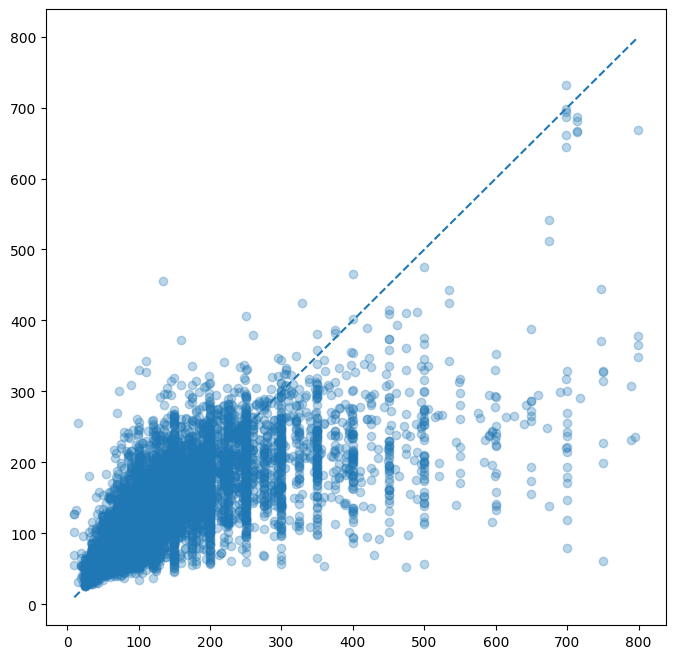

In [77]:
plt.figure(
    figsize=(8, 8)
)

plt.scatter(
    y_test,
    final_test_pred,
    alpha=0.3
)

minimum_value = min(
    y_test.min(),
    final_test_pred.min()
)

maximum_value = max(
    y_test.max(),
    final_test_pred.max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--"
)

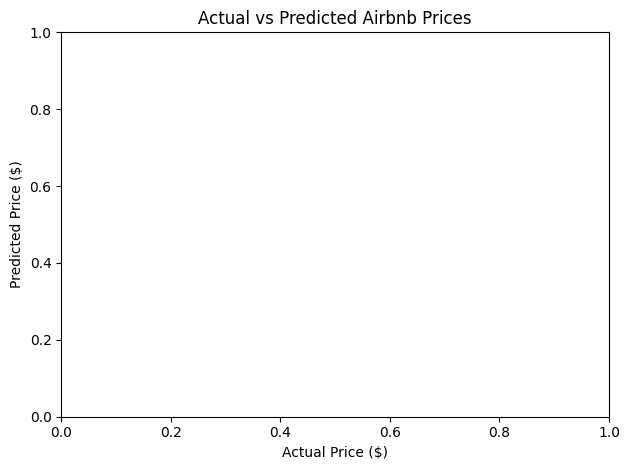

In [78]:
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Actual vs Predicted Airbnb Prices")
plt.tight_layout()
plt.show()

### Residual Analysis

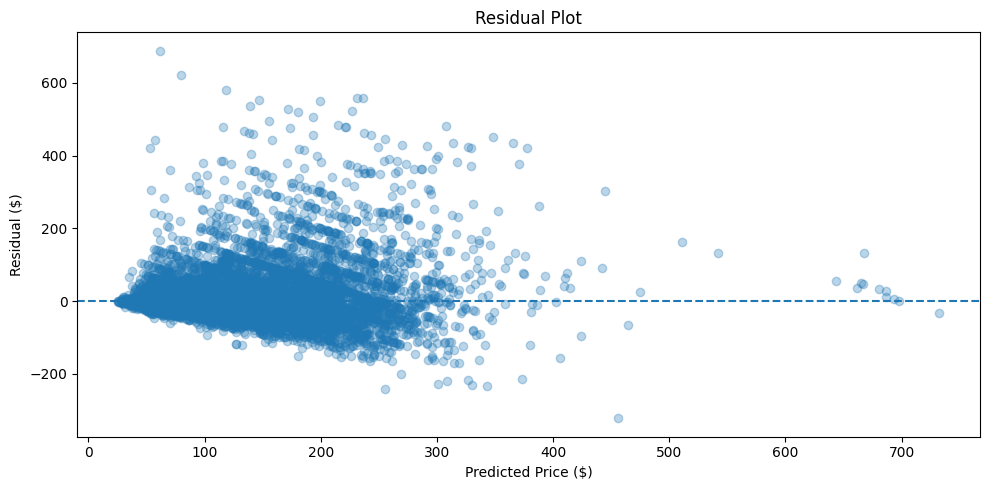

In [79]:
residuals = (
    y_test -
    final_test_pred
)

plt.figure(
    figsize=(10, 5)
)

plt.scatter(
    final_test_pred,
    residuals,
    alpha=0.3
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Price ($)")
plt.ylabel("Residual ($)")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()

### Saving Final Model

In [80]:
MODEL_PATH = "airbnb_price_prediction_final.pkl"

In [81]:
joblib.dump(
    final_model,
    MODEL_PATH
)

print("\n" + "=" * 70)
print("MODEL SAVED")
print("=" * 70)

print(
    f"Saved to: {MODEL_PATH}"
)


MODEL SAVED
Saved to: airbnb_price_prediction_final.pkl


### Saving Model Results

In [82]:
final_comparison.to_csv(
    "airbnb_model_comparison.csv",
    index=False
)

In [83]:
pd.DataFrame({
    "Metric": [
        "Test MAE",
        "Test RMSE",
        "Test R2",
        "Train R2",
        "R2 Gap"
    ],
    "Value": [
        final_test_mae,
        final_test_rmse,
        final_test_r2,
        final_train_r2,
        r2_gap
    ]
}).to_csv(
    "airbnb_final_metrics.csv",
    index=False
)

In [84]:
pd.DataFrame({
    "Actual_Price": y_test.values,
    "Predicted_Price": final_test_pred
}).assign(
    Absolute_Error=lambda x:
        abs(
            x["Actual_Price"]
            -
            x["Predicted_Price"]
        )
).to_csv(
    "airbnb_test_predictions.csv",
    index=False
)

### Testing

In [85]:
loaded_model = joblib.load(
    MODEL_PATH
)

In [86]:
saved_model_predictions = loaded_model.predict(
    X_test.iloc[:5]
)

In [87]:
print("Predictions from the saved model:\n")

for prediction in saved_model_predictions:
    print(
        f"${prediction:.2f}"
    )

Predictions from the saved model:

$122.52
$182.09
$60.67
$54.22
$35.89


In [88]:
print("Task1 and Task 2 Completed-\n")

print("Final model:", best_model_name)
print(f"Test MAE : ${final_test_mae:.2f}")
print(f"Test RMSE: ${final_test_rmse:.2f}")
print(f"Test R2  : {final_test_r2:.4f}")
print("Model file:", MODEL_PATH)

Task1 and Task 2 Completed-

Final model: Tuned Random Forest
Test MAE : $41.79
Test RMSE: $72.66
Test R2  : 0.5148
Model file: airbnb_price_prediction_final.pkl
